# Assignment 11: Customer Segmentation Project

**Course Outcome**: CO4  
**Topic**: K-Means Clustering, Elbow Method Optimization & Strategic Business Translation  

### Objectives:
1. Apply K-Means Clustering to customer transactional & demographic data.
2. Empirically determine and justify the optimal number of clusters using the **Elbow Method** and Silhouette Analysis.
3. Visualize the 2D cluster spaces with distinct centroids.
4. Formulate an actionable marketing interpretation for every discovered customer segment.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('Setup initialized successfully!')

Setup initialized successfully!


## 1. Load Mall Customer Data
We inspect the customer records containing `Annual_Income_k`, `Spending_Score`, and `Age`.

In [2]:
df = pd.read_csv('mall_customers.csv')
print(f'Dataset Dimensions: {df.shape}')
df.head()

Dataset Dimensions: (200, 4)


,CustomerID,Age,Annual_Income_k,Spending_Score
0,96,41,60.1,36
1,16,41,21.6,24
2,31,36,21.4,31
3,159,59,86.6,5
4,129,37,89.2,18


## 2. Determining Optimal Clusters: The Elbow Method
We iterate $k$ from 1 to 10 and compute the Within-Cluster Sum of Squares (Inertia) and Silhouette Scores.

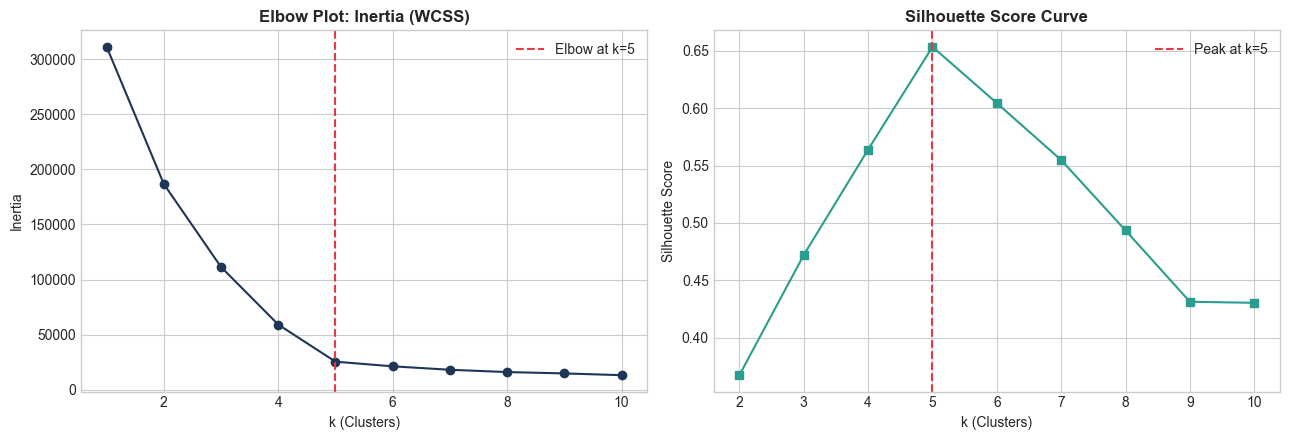

In [3]:
X = df[['Annual_Income_k', 'Spending_Score']].values

k_values = range(1, 11)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_values), inertias, 'o-', color='#1d3557')
axes[0].axvline(5, color='#e63946', linestyle='--', label='Elbow at k=5')
axes[0].set_title('Elbow Plot: Inertia (WCSS)', fontweight='bold')
axes[0].set_xlabel('k (Clusters)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].plot(list(range(2, 11)), sil_scores, 's-', color='#2a9d8f')
axes[1].axvline(5, color='#e63946', linestyle='--', label='Peak at k=5')
axes[1].set_title('Silhouette Score Curve', fontweight='bold')
axes[1].set_xlabel('k (Clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Fit Final K-Means ($k=5$) & Visualize Clusters
The elbow inflection clearly occurs at $k=5$, coinciding with the silhouette score peak.

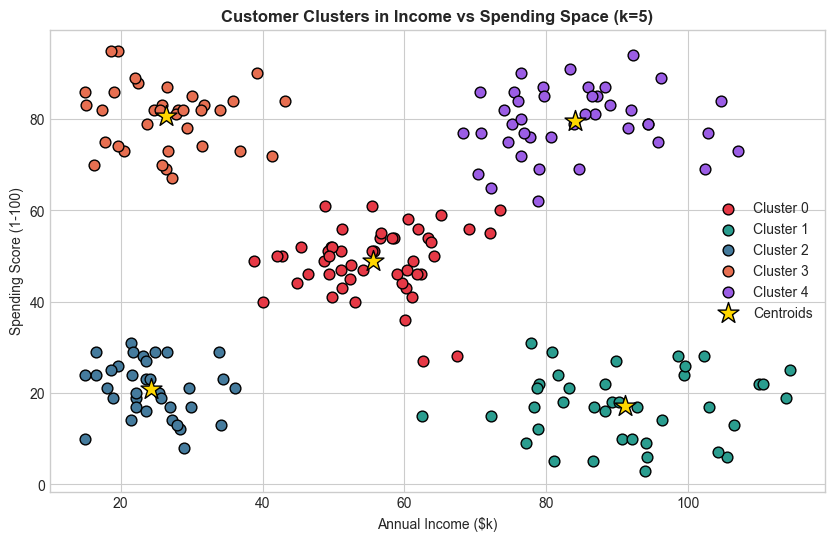

In [4]:
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=20, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 6))
palette = ['#e63946', '#2a9d8f', '#457b9d', '#e76f51', '#9b5de5']
for c in range(5):
    c_df = df[df['Cluster'] == c]
    plt.scatter(c_df['Annual_Income_k'], c_df['Spending_Score'], s=60, color=palette[c], label=f'Cluster {c}', edgecolor='black')
plt.scatter(centroids[:, 0], centroids[:, 1], s=250, marker='*', color='gold', edgecolor='black', label='Centroids', zorder=10)
plt.title('Customer Clusters in Income vs Spending Space (k=5)', fontweight='bold')
plt.xlabel('Annual Income ($k)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## 4. Segment Profiling & Business Interpretation
We compute segment averages and outline tailored marketing actions.

In [5]:
profile = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Income=('Annual_Income_k', 'mean'),
    Avg_Spending=('Spending_Score', 'mean'),
    Avg_Age=('Age', 'mean')
).reset_index()
profile

,Cluster,Count,Avg_Income,Avg_Spending,Avg_Age
0,0,50,55.544000,48.880000,41.520000
1,1,39,91.123077,17.128205,39.897436
2,2,35,24.260000,20.971429,43.800000
3,3,35,26.417143,80.571429,25.857143
4,4,41,83.973171,79.512195,32.024390


## 5. Strategic Marketing Action Plan

1. **VIP Luxury Spenders (High Income, High Spending)**: Core revenue driver. Deploy concierge services, premium product previews, and exclusive loyalty rewards.
2. **Careful Savers (High Income, Low Spending)**: Untapped potential. High financial capacity but skeptical. Target with value-oriented luxury messaging, investment grade durability, and financial perks.
3. **Impulsive Trend-Seekers (Low Income, High Spending)**: High engagement, younger demographic. Market trendy, fast-fashion items, limited drops, and flexible BNPL (Buy Now Pay Later) payment methods.
4. **Budget / Value Shoppers (Low Income, Low Spending)**: Price sensitive. Target with clearance sales, coupons, and budget staples.
5. **Mainstream Core (Moderate Income, Moderate Spending)**: Steady foot traffic. Standard promotional campaigns and general rewards programs.